In [1]:
from groq_llm import get_groq_llm
from langchain.messages import HumanMessage, AIMessage
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END

import json

In [ ]:
class LegalSchema(TypedDict):
    query: str
    tools: List[str] = ["legal_rag", "user_files", "web_search"]
    rag_context : str

In [3]:
llm = get_groq_llm()

In [135]:
#llm.invoke([HumanMessage("Hello how are you?")]).content

In [ ]:
def router_node(state: dict):
    query = state["query"]

    prompt = f"""
You are a legal AI routing engine.

You MUST return ONLY valid JSON.

Schema:

  "query": "string (optimized query)",
  "tools": ["legal_rag", "user_files", "web_search"]
Rules:
- Output ONLY JSON
- No markdown
- No explanation

User Query:
{query}
"""

    response = llm.invoke(prompt)
    
    return json.loads(response.content)   

In [44]:
res = router_node({"query": "What is the statute of limitations for a breach of contract in California?"})

In [56]:
True if 'legal_rag' in res["tools"] else False

True

In [57]:
res

{'query': 'California statute of limitations for breach of contract',
 'tools': ['legal_rag', 'web_search']}

In [63]:
def legal_rag(state: LegalSchema) -> LegalSchema:
    return "Rag Used"

def user_files(state: LegalSchema) -> LegalSchema:
    return "User Files Used"

def web_search(state: LegalSchema) -> LegalSchema:
    return "Web Search Used"

def context_collector():
    return "Collected Context"

In [64]:
def conditioner(state: LegalSchema) ->LegalSchema:
    tools = state['tools']

    routes = []

    if 'legal_rag' in tools:
        routes.append('legal_rag')
    if 'user_files' in tools:
        routes.append('user_files')
    if 'web_search' in tools:
        routes.append('web_search')
        
    return routes

In [65]:
graph = StateGraph(LegalSchema)

graph.add_node("router_node", router_node)
graph.add_node("user_files", user_files)
graph.add_node("legal_rag", legal_rag)
graph.add_node("web_search", web_search)
graph.add_node("context_collector", context_collector)


graph.add_edge(START, "router_node")
graph.add_conditional_edges("router_node", conditioner, {
    "legal_rag": "legal_rag",
    "user_files": "user_files",
    "web_search": "web_search"
})
graph.add_edge("legal_rag", "context_collector")
graph.add_edge("user_files", "context_collector")
graph.add_edge("web_search", "context_collector")

graph.add_edge("context_collector", END)
gf = graph.compile()

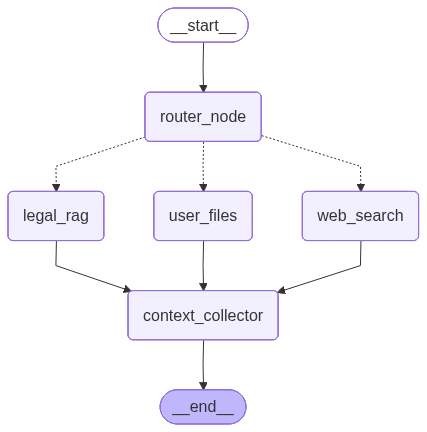

In [66]:
### Show graph structure
gf

In [67]:
gf.invoke({"query": "what is the statute of limitations for a personal injury case "})

InvalidUpdateError: Expected dict, got Web Search Used
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/INVALID_GRAPH_NODE_RETURN_VALUE